# Reto: Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

---

## Objetivo del notebook

Este notebook consolida el trabajo de los tres avances del reto **Spaceship
Titanic** en un solo documento de referencia: preprocesamiento y feature
engineering (Avance 1), selección de familia de modelo y exploración inicial
de hiperparámetros (Avance 2), y diagnóstico, tuning fino, componente
individual y decisión final (Avance 3).

El objetivo **no es corregir ni repetir** el trabajo ya hecho, sino
**justificar de forma consolidada** las decisiones que llevaron al modelo
final, con las gráficas y el razonamiento más importantes de cada etapa.
Para el detalle completo de cada análisis (EDA exhaustivo, todas las
corridas de búsqueda de hiperparámetros, las 5 subsecciones individuales
completas, etc.), este notebook cita el avance correspondiente — el detalle
íntegro vive en `Notebooks/`, dentro de este mismo repositorio.

Al final, el notebook entrena la corrida óptima de los dos modelos que el
equipo dejó como estrategia final (Random Forest tuneado y SVC tuneado) y
los exporta con `joblib`, junto con el preprocesador, para alimentar
directamente la interfaz/dashboard de la siguiente etapa del reto.

**Nota sobre reproducibilidad:** a diferencia de los avances individuales,
aquí no se ejecutan búsquedas de hiperparámetros completas (`GridSearchCV`/
`RandomizedSearchCV`) — se usan directamente los mejores hiperparámetros ya
encontrados y documentados en los avances correspondientes, para que este
notebook corra de principio a fin en minutos, no en horas.

Este notebook está organizado en las siguientes secciones:

1. Carga de Datos
2. Preprocesamiento y Feature Engineering
3. Selección de Familia de Modelo
4. Diagnóstico y Tuning del Modelo Base
5. Resultados del Componente Individual
6. Modelo Final — Estrategia Dual (SVC + Random Forest)
7. Exportación de Modelos
8. Conclusión Final del Equipo
9. Apéndice A — Deck como Variable Ordinal
10. Apéndice B — Verificación de Varianza por `group_size`

# 1. Carga de Datos

Partimos de los datos crudos de Kaggle (`train.csv`/`test.csv`), igual que
en el Avance 1, para que este notebook sea autocontenido y no dependa de
archivos intermedios que no estén en el repositorio.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path("..") / "data"
RANDOM_STATE = 42

df_train = pd.read_csv(DATA / "train.csv")
df_test = pd.read_csv(DATA / "test.csv")

print("train:", df_train.shape)
print("test: ", df_test.shape)
df_train.head()

train: (8693, 14)
test:  (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# 2. Preprocesamiento y Feature Engineering

Consolidamos aquí el feature engineering completo del Avance 1
(`Notebooks/Reto_Primer_Avance_Spaceship_Titanic.ipynb`, Secciones 3 a 7),
encapsulado como una clase (`SpaceshipPreprocessor`) que implementa la
interfaz `fit`/`transform` de scikit-learn. Esto cumple con la recomendación
del profesor de usar objetos, y además hace que el mismo preprocesamiento
se pueda reutilizar tanto aquí como en la interfaz/dashboard final, sin
duplicar lógica.

**Diferencia clave respecto al Avance 1:** las estadísticas de imputación
(medianas, modas) y el escalador se **ajustan una sola vez sobre `train`**
(`fit`) y luego se **aplican tal cual** sobre cualquier dato nuevo
(`transform`) — incluyendo test.csv y, más adelante, pasajeros individuales
en el dashboard. En el notebook original estas estadísticas se recalculaban
sobre el mismo dataframe que se procesaba, lo cual es correcto para un
análisis de una sola pasada pero no es viable para predecir sobre datos
nuevos uno a la vez.

Para el detalle completo del EDA que justifica cada decisión (por qué se
descartan `VIP`/`Name`, por qué `log1p`+`RobustScaler`, por qué bins de 300
en `CabinNum`, etc.), ver Avance 1, Secciones 2 a 7. Aquí solo se retoma el
resultado ya justificado.

In [2]:
from preprocessing import SpaceshipPreprocessor, SPEND_COLS

**Nota:** el código de `SpaceshipPreprocessor` se movió a `preprocessing.py`
(ver Sección 2) para que tanto este notebook como el backend de la interfaz
puedan importar la misma clase sin duplicar lógica — necesario porque
`joblib` guarda una referencia al módulo donde se definió la clase, y
`__main__` (el notebook) no es importable fuera de Jupyter. Se deja aquí,
comentado, el código original tal como vivía en el notebook antes de
moverlo, por trazabilidad y para no perder el historial de la decisión.

In [3]:
"""
Esto es un ejemplo de cómo usar la clase SpaceshipPreprocessor para preprocesar los datos de entrenamiento y prueba.

from preprocessing import SpaceshipPreprocessor

SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

class SpaceshipPreprocessor(BaseEstimator, TransformerMixin):

    Replica el feature engineering del Avance 1 (Secciones 3-7) como un
    objeto reusable. fit() aprende estadísticas SOLO de los datos de
    entrenamiento; transform() las aplica a cualquier dato nuevo.
 

    def __init__(self):
        self.bins_cabin = [-np.inf, 299, 599, 899, 1199, 1499, np.inf]
        self.labels_cabin = ["0-299", "300-599", "600-899", "900-1199", "1200-1499", "1500+"]

    def fit(self, X, y=None):
        df = X.copy()
        df = df.drop(columns=["Name", "VIP"], errors="ignore")

        df["Deck"] = df["Cabin"].str.split("/").str[0]
        df["CabinNum"] = pd.to_numeric(df["Cabin"].str.split("/").str[1], errors="coerce")
        df["Side"] = df["Cabin"].str.split("/").str[2]
        gastos_totales = df[SPEND_COLS].sum(axis=1)
        df.loc[df["CryoSleep"].isnull() & (gastos_totales > 0), "CryoSleep"] = False

        self.medianas_ = {col: df[col].median() for col in ["Age", "CabinNum"] + SPEND_COLS}
        self.modas_ = {col: df[col].mode()[0] for col in ["HomePlanet", "Destination", "CryoSleep", "Deck", "Side"]}

        df_imputado = self._imputar(df)
        df_codificado = self._codificar(df_imputado)
        self.cols_to_scale_ = ["Age", "group_size"] + SPEND_COLS
        self.scaler_ = RobustScaler()
        self.scaler_.fit(df_codificado[self.cols_to_scale_])

        self.columnas_finales_ = self._escalar(df_codificado.copy()).drop(columns=["Transported"], errors="ignore").columns

        return self

    def transform(self, X):
        df = X.copy()
        df = df.drop(columns=["Name", "VIP"], errors="ignore")

        df["Deck"] = df["Cabin"].str.split("/").str[0]
        df["CabinNum"] = pd.to_numeric(df["Cabin"].str.split("/").str[1], errors="coerce")
        df["Side"] = df["Cabin"].str.split("/").str[2]
        gastos_totales = df[SPEND_COLS].sum(axis=1)
        df.loc[df["CryoSleep"].isnull() & (gastos_totales > 0), "CryoSleep"] = False

        df = self._imputar(df)
        df = self._codificar(df)
        df = self._escalar(df)

        target = df["Transported"] if "Transported" in df.columns else None
        df = df.reindex(columns=self.columnas_finales_, fill_value=0)
        if target is not None:
            df["Transported"] = target

        return df

    def _imputar(self, df):
        for col in SPEND_COLS:
            df.loc[(df["CryoSleep"] == True) & (df[col].isnull()), col] = 0.0
        for col in ["Age", "CabinNum"] + SPEND_COLS:
            df[col] = df[col].fillna(self.medianas_[col])
        for col in ["HomePlanet", "Destination", "CryoSleep", "Deck", "Side"]:
            df[col] = df[col].fillna(self.modas_[col])
        return df

    def _codificar(self, df):
        df["group"] = df["PassengerId"].str.split("_").str[0]
        df["group_size"] = df["group"].map(df["group"].value_counts())
        df.drop(columns=["Cabin", "PassengerId", "group"], inplace=True, errors="ignore")

        df["CabinNumBin"] = pd.cut(df["CabinNum"], bins=self.bins_cabin, labels=self.labels_cabin)
        df.drop(columns=["CabinNum"], inplace=True)

        df["HasSpent"] = (df[SPEND_COLS].sum(axis=1) > 0).astype(int)
        df["CryoSleep"] = df["CryoSleep"].astype(int)
        df["Side"] = df["Side"].map({"P": 0, "S": 1})
        if "Transported" in df.columns:
            df["Transported"] = df["Transported"].astype(int)

        df = pd.get_dummies(df, columns=["HomePlanet", "Destination", "Deck", "CabinNumBin"], drop_first=True, dtype=int)
        return df

    def _escalar(self, df):
        for col in SPEND_COLS:
            df[col] = np.log1p(df[col])
        df[self.cols_to_scale_] = self.scaler_.transform(df[self.cols_to_scale_])
        return df

"""

'\nEsto es un ejemplo de cómo usar la clase SpaceshipPreprocessor para preprocesar los datos de entrenamiento y prueba.\n\nfrom preprocessing import SpaceshipPreprocessor\n\nSPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]\n\nclass SpaceshipPreprocessor(BaseEstimator, TransformerMixin):\n\n    Replica el feature engineering del Avance 1 (Secciones 3-7) como un\n    objeto reusable. fit() aprende estadísticas SOLO de los datos de\n    entrenamiento; transform() las aplica a cualquier dato nuevo.\n\n\n    def __init__(self):\n        self.bins_cabin = [-np.inf, 299, 599, 899, 1199, 1499, np.inf]\n        self.labels_cabin = ["0-299", "300-599", "600-899", "900-1199", "1200-1499", "1500+"]\n\n    def fit(self, X, y=None):\n        df = X.copy()\n        df = df.drop(columns=["Name", "VIP"], errors="ignore")\n\n        df["Deck"] = df["Cabin"].str.split("/").str[0]\n        df["CabinNum"] = pd.to_numeric(df["Cabin"].str.split("/").str[1], errors="coerce")\n       

In [4]:
preprocesador = SpaceshipPreprocessor()
preprocesador.fit(df_train)

df_prep = preprocesador.transform(df_train)

print("Shape df_prep:", df_prep.shape)
print("Nulos totales:", df_prep.isnull().sum().sum())
df_prep.head()

Shape df_prep: (8693, 27)
Nulos totales: 0


,CryoSleep,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Side,group_size,HasSpent,...,Deck_E,Deck_F,Deck_G,Deck_T,CabinNumBin_300-599,CabinNumBin_600-899,CabinNumBin_900-1199,CabinNumBin_1200-1499,CabinNumBin_1500+,Transported
0,0,0.705882,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,-0.176471,0.114646,0.037747,0.148095,0.119055,0.095167,1,0.0,1,...,0,1,0,0,0,0,0,0,0,1
2,0,1.823529,0.092297,0.134136,0.000000,0.166269,0.097801,1,0.5,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0.352941,0.000000,0.117340,0.269041,0.153033,0.131696,1,0.5,1,...,0,0,0,0,0,0,0,0,0,0
4,0,-0.647059,0.139440,0.069880,0.228358,0.119596,0.027465,1,0.0,1,...,0,1,0,0,0,0,0,0,0,1


# 3. Selección de Familia de Modelo

Antes de tunear nada, el Avance 2 partió de dos preguntas: ¿qué métricas
tienen sentido para este problema?, y ¿qué familia de modelo conviene
profundizar? Aquí resumimos ese proceso; el detalle completo (incluyendo la
exploración individual de hiperparámetros de cada integrante) está en
`Notebooks/Reto_Segundo_Avance.ipynb`, Secciones 2 a 5.

**Métricas elegidas:** con las clases prácticamente balanceadas (~50.4% /
49.6%), Accuracy es una métrica confiable como referencia general. Se
complementa con Precision, Recall y F1-score porque, aunque Accuracy resume
el desempeño global, no distingue qué tipo de error comete el modelo — y en
este problema no hay una razón de negocio para preferir evitar falsos
positivos sobre falsos negativos, así que F1 (que balancea ambos) es la
métrica compuesta de referencia.

In [5]:
from sklearn.model_selection import train_test_split

X = df_prep.drop(columns=["Transported"])
y = df_prep["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

clase_mayoritaria = y.mode()[0]
baseline_accuracy = (y == clase_mayoritaria).mean()

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print(f"Baseline (accuracy): {baseline_accuracy:.4f}")

X_train: (6954, 26) X_test: (1739, 26)
Baseline (accuracy): 0.5036


**Baseline:** predecir siempre la clase mayoritaria da un accuracy de
~0.5036 — cualquier modelo debe superar esto claramente para justificar su
uso.

**Dos modelos de familias distintas** para tener un punto de comparación
real antes de profundizar en uno solo:

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modelo_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

modelo_rf_base = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)
modelo_rf_base.fit(X_train, y_train)
y_pred_rf_base = modelo_rf_base.predict(X_test)

resultados = pd.DataFrame({
    "Modelo": ["Baseline", "Regresión Logística", "Random Forest"],
    "Accuracy": [baseline_accuracy, accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf_base)],
    "Precision": [None, precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf_base)],
    "Recall": [None, recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_rf_base)],
    "F1-score": [None, f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_rf_base)],
})
resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline,0.503624,NaN,NaN,NaN
1,Regresión Logística,0.784359,0.796450,0.768265,0.782103
2,Random Forest,0.798735,0.800915,0.799087,0.800000


## Elección de familia de modelo

Random Forest superó a Regresión Logística en Accuracy (+0.0052), Precision
(+0.0140) y F1-score (+0.0020), pero perdió en Recall (−0.0103) — una
mejora pequeña, no aplastante. Se eligió **Random Forest** no porque "gane
en todo", sino porque fue la única métrica compuesta (F1) donde hubo mejora
consistente, y porque un ensamble de árboles tiene más margen de mejora vía
tuning de hiperparámetros que una Regresión Logística.

La exploración individual de hiperparámetros del Avance 2 (Sección 5 — cada
integrante varió un hiperparámetro distinto de Random Forest:
`min_samples_leaf`, `max_depth`, `min_samples_split`, `n_estimators`)
confirmó que ningún cambio aislado producía una mejora clara, lo cual
motivó el diagnóstico más riguroso (curvas de aprendizaje/validación) que
se hizo en el Avance 3, Sección 1 — ver Sección 4 de este notebook.

# 4. Diagnóstico y Tuning del Modelo Base

Esta sección resume el Avance 3, Secciones 1 y 2. El detalle completo —
incluyendo la curva de validación de `min_samples_leaf` y la tabla completa
de resultados de `RandomizedSearchCV` — está en
`Notebooks/Reto_Tercer_Avance_Spaceship_Titanic.ipynb`. Aquí se reproduce el
razonamiento completo por escrito, pero la búsqueda de hiperparámetros en sí
**no se vuelve a ejecutar** (sería repetir ~100 entrenamientos de Random
Forest solo para llegar al mismo resultado ya documentado); en su lugar, se
reconstruye el modelo directamente con los mejores hiperparámetros ya
encontrados.

## 4.1 Curva de aprendizaje

Usamos F1-score como métrica en todas las curvas de diagnóstico (en vez de
Accuracy) porque resume en un solo número el balance entre precision y
recall — que en el Avance 2 vimos que se mueven en direcciones opuestas al
cambiar hiperparámetros de Random Forest — y porque es la métrica que el
equipo usó para decidir entre modelos.

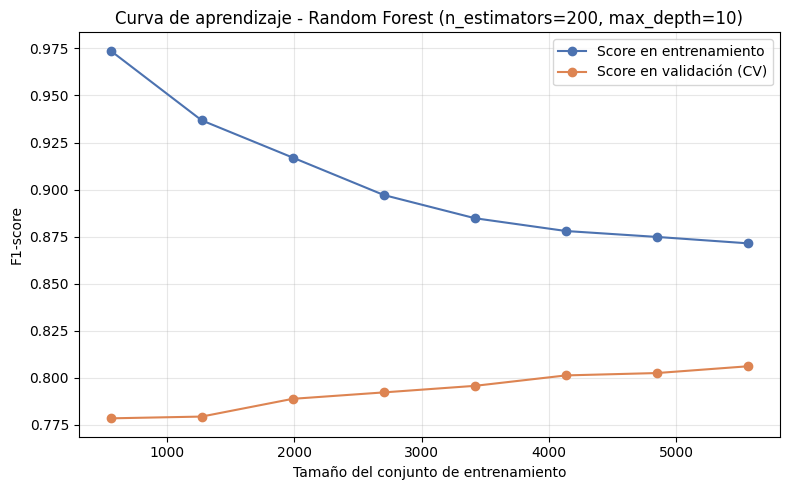

In [7]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

modelo_base = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    modelo_base, X_train, y_train, cv=5, scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=RANDOM_STATE, n_jobs=-1,
)
train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(train_sizes, val_mean, "o-", color="#DD8452", label="Score en validación (CV)")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score")
plt.title("Curva de aprendizaje - Random Forest (n_estimators=200, max_depth=10)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

La curva muestra **overfitting moderado y decreciente**: el score en
entrenamiento baja de 0.974 a 0.871 conforme crece el dataset, mientras el
de validación sube de 0.778 a 0.807 — la brecha se reduce de ~0.20 a ~0.065
pero no se cierra del todo. No parece ser underfitting (el score de
validación mejora consistentemente, no se estanca desde el inicio en un
valor bajo). La pendiente de la curva de validación ya es pequeña al final,
así que el margen de mejora solo por más datos parece limitado — algo que
tampoco podemos controlar, ya que el tamaño de `train.csv` es fijo. Esto
apunta a que el tuning debe enfocarse en **limitar la complejidad del árbol
individual** (`max_depth`, `min_samples_leaf`, `min_samples_split`) en vez
de buscar modelos más complejos.

## 4.2 Curvas de validación

Para no repetir aquí las dos curvas completas (ver Avance 3, Sección 1 para
el detalle de `min_samples_leaf`), mostramos la más decisiva — `max_depth`
— y resumimos ambas:

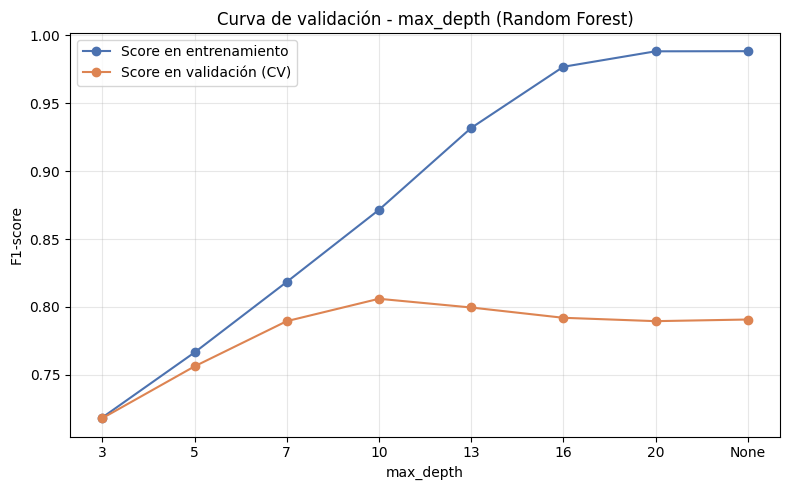

In [8]:
from sklearn.model_selection import validation_curve

rango_max_depth = [3, 5, 7, 10, 13, 16, 20, None]
train_scores_md, val_scores_md = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_train, y_train, param_name="max_depth", param_range=rango_max_depth,
    cv=5, scoring="f1", n_jobs=-1,
)
val_mean_md = val_scores_md.mean(axis=1)
etiquetas_md = [str(v) for v in rango_max_depth]

plt.figure(figsize=(8, 5))
plt.plot(etiquetas_md, train_scores_md.mean(axis=1), "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(etiquetas_md, val_mean_md, "o-", color="#DD8452", label="Score en validación (CV)")
plt.xlabel("max_depth"); plt.ylabel("F1-score")
plt.title("Curva de validación - max_depth (Random Forest)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**`max_depth`:** pico claro de generalización en `max_depth=10` (F1
val=0.806). Antes de ese punto (3-7) hay underfitting: train y val suben
juntos porque el árbol es demasiado simple. Después de 10, el train sigue
subiendo hasta casi memorizar el dataset (0.988) mientras el val se estanca
o baja — overfitting creciente sin beneficio. Esto confirma que
`max_depth=10` no fue un valor arbitrario en el Avance 2.

**`min_samples_leaf`** (ver gráfica completa en Avance 3, Sección 1): a
diferencia de `max_depth`, aquí no hay un pico donde el val mejore al subir
el hiperparámetro — el val se mantiene casi plano entre 1 y 5 (0.806-0.807)
y luego baja. La brecha train-val sí se cierra, pero porque el train
empeora, no porque el val mejore.

**Rango a explorar en el tuning:** `max_depth` entre 8 y 14 (centrado en el
pico observado), `min_samples_leaf` entre 1 y 5 (zona donde el val se
mantiene en su mejor nivel). Se agregan `n_estimators` y
`min_samples_split` a la grilla aunque no se graficaron aquí, porque
interactúan con `max_depth` y pueden desplazar ligeramente el óptimo
conjunto.

## 4.3 Tuning de hiperparámetros

**¿GridSearchCV o RandomizedSearchCV?** El espacio combinando los 5
hiperparámetros (`n_estimators`: 4 valores, `max_depth`: 7,
`min_samples_leaf`: 5, `min_samples_split`: 5, `max_features`: 3) tiene
2,100 combinaciones posibles. Con `cv=5`, un `GridSearchCV` exhaustivo
implicaría 10,500 entrenamientos — costoso para la ganancia marginal que ya
anticipan las curvas de validación (el margen de mejora es pequeño). Se usó
**`RandomizedSearchCV`** con `n_iter=20`: al ya conocer la región donde
está el óptimo (`max_depth` 8-14, `min_samples_leaf` bajo), no se necesita
explorar las 2,100 combinaciones completas para encontrar un buen punto
dentro de esa región.

**K-Fold:** `K=5` — mismo valor usado en las curvas de diagnóstico
(comparabilidad directa), y adecuado para un dataset de ~7,000 filas
balanceado: folds lo bastante grandes para ser estables, sin sacrificar
demasiados datos de entrenamiento en cada fold.

**Métricas de evaluación:** F1-score como criterio principal de la
búsqueda (resume el trade-off precision/recall), y ROC-AUC como segunda
métrica, porque evalúa la calidad del ranking de probabilidades en todos
los umbrales, no solo en 0.5 — confirma si la mejora es robusta o depende
de un ajuste específico del umbral.

**Resultado de la búsqueda (Avance 3, Sección 2):** los mejores
hiperparámetros encontrados fueron `max_depth=12`, `min_samples_leaf=5`,
`min_samples_split=5`, `n_estimators=300`, `max_features="sqrt"`, con
F1 en CV = 0.8100 y ROC-AUC en CV = 0.8888. Aquí reconstruimos el modelo
directamente con esos hiperparámetros, sin repetir la búsqueda:

In [9]:
modelo_rf_tuned = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    min_samples_split=5, max_features="sqrt", random_state=RANDOM_STATE,
)
modelo_rf_tuned.fit(X_train, y_train)

print("Modelo RF tuneado reconstruido con los hiperparámetros óptimos del Avance 3.")

Modelo RF tuneado reconstruido con los hiperparámetros óptimos del Avance 3.


La mejora del F1 en CV (0.8100) sobre el Random Forest base del Avance 2
(~0.8000) es real pero modesta (~+0.01), consistente con lo que anticipaban
las curvas: el modelo base ya estaba cerca de un buen equilibrio
sesgo-varianza. Los hiperparámetros ganadores apuntan en la misma
dirección que el diagnóstico — una profundidad ligeramente mayor a 10 pero
compensada con hojas y splits más exigentes (más regularización), no un
árbol simplemente más profundo sin control.

# 5. Resultados del Componente Individual

En el Avance 3 (Sección 4), cada integrante tuneó un modelo de familia
distinta a Random Forest y entre sí, evaluándolo con las mismas métricas
del equipo (F1-score, ROC-AUC, y las 4 métricas base). El detalle completo
de cada tuning, matriz de confusión y curva ROC está en
`Notebooks/Reto_Tercer_Avance_Spaceship_Titanic.ipynb`, Sección 4. Aquí se
resume el resultado y la decisión de cada quien.

In [10]:
F1_RF, ROC_AUC_RF = 0.8050, 0.8984  # valores del RF tuneado del equipo sobre el mismo test set

resumen_individual = pd.DataFrame({
    "Integrante": ["Ana Paula Moreno", "David Tinoco Romero", "Emilio Páez de la Mora", "Emilio Torres Paul", "Alejandro Vázquez"],
    "Modelo": ["Regresión Logística", "SVC", "KNN", "Naive Bayes", "Red Neuronal (MLP)"],
    "F1-score": [0.7934, 0.8106, 0.7603, 0.7068, 0.7917],
    "F1 RF a superar": [F1_RF] * 5,
    "ROC-AUC": [0.8677, 0.8945, 0.8747, 0.7876, 0.8881],
    "ROC-AUC RF a superar": [ROC_AUC_RF] * 5,
    "¿Superó al RF del equipo?": ["No", "Sí", "No", "No", "No"],
    "¿Cambiaría la decisión?": ["No", "Sí", "No", "No", "No"],
})
resumen_individual

,Integrante,Modelo,F1-score,F1 RF a superar,ROC-AUC,ROC-AUC RF a superar,¿Superó al RF del equipo?,¿Cambiaría la decisión?
0,Ana Paula Moreno,Regresión Logística,0.7934,0.805,0.8677,0.8984,No,No
1,David Tinoco Romero,SVC,0.8106,0.805,0.8945,0.8984,Sí,Sí
2,Emilio Páez de la Mora,KNN,0.7603,0.805,0.8747,0.8984,No,No
3,Emilio Torres Paul,Naive Bayes,0.7068,0.805,0.7876,0.8984,No,No
4,Alejandro Vázquez,Red Neuronal (MLP),0.7917,0.805,0.8881,0.8984,No,No


**Hallazgos por integrante:**

- **Ana Paula Moreno (Regresión Logística):** modelo lineal usado como
  referencia interpretable; quedó por debajo del Random Forest tuneado en
  las métricas compuestas, consistente con que el problema tiene relaciones
  no lineales que un modelo lineal no captura tan bien.
- **David Tinoco Romero (SVC):** el único modelo individual que **superó**
  al Random Forest del equipo en todas las métricas — este resultado es
  justo el que después motivó la estrategia dual de la Sección 6.
- **Emilio Páez de la Mora (KNN):** quedó por debajo del RF en las cinco
  métricas, sobre todo en Recall (0.7249 vs 0.8082). La causa identificada
  fue estructural: con ~26 dimensiones (varias dummies de baja
  cardinalidad), la "maldición de la dimensionalidad" diluye la noción de
  cercanía que usa KNN para votar.
- **Emilio Torres Paul (Naive Bayes):** quedó por debajo del RF; el
  supuesto de independencia condicional entre variables de Naive Bayes es
  poco realista aquí (p. ej., `CryoSleep` y las variables de gasto están
  fuertemente correlacionadas por construcción).
- **Alejandro Vázquez (Red Neuronal / MLP):** quedó por debajo del RF; con
  un dataset de tamaño moderado (~7,000 filas de entrenamiento), una red
  neuronal no tiene suficiente volumen de datos para superar a un ensamble
  de árboles ya bien ajustado.

**Conclusión de la sección:** de los cinco modelos individuales, **solo el
SVC de David superó al Random Forest del equipo**, y lo hizo en las cinco
métricas. Este hallazgo es la base de la decisión de la Sección 6.

# 6. Modelo Final — Estrategia Dual

En la Sección 5 vimos que el SVC de David fue el único modelo individual
que superó al Random Forest tuneado del equipo, en las cinco métricas. Por
eso el Avance 3 (Sección 6) no eligió un solo "ganador", sino una
**estrategia dual**: usar el modelo que mejor se ajuste al contexto de
implementación. Aquí reconstruimos ambos modelos con su configuración
óptima ya encontrada (sin repetir las búsquedas) y los comparamos
directamente.

In [11]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Random Forest tuneado: ya se construyó en la Sección 4 (modelo_rf_tuned)

# SVC tuneado: hiperparámetros ganadores del GridSearchCV refinado del Avance 3
# (Sección 4 — David), sobre el espacio explorado con RandomizedSearchCV primero
modelo_svc_final = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(C=150, gamma=0.005, kernel="rbf", probability=True, random_state=RANDOM_STATE)),
])
modelo_svc_final.fit(X_train, y_train)

print("SVC final reconstruido con los hiperparámetros óptimos del Avance 3.")

C:\Users\paeze\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC final reconstruido con los hiperparámetros óptimos del Avance 3.


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def calcular_metricas(modelo, X, y):
    y_pred = modelo.predict(X)
    y_proba = modelo.predict_proba(X)[:, 1]
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-score": f1_score(y, y_pred),
        "ROC-AUC": roc_auc_score(y, y_proba),
    }

comparacion_final = pd.DataFrame({
    "Random Forest tuneado": calcular_metricas(modelo_rf_tuned, X_test, y_test),
    "SVC tuneado": calcular_metricas(modelo_svc_final, X_test, y_test),
})
comparacion_final["Diferencia (SVC - RF)"] = comparacion_final["SVC tuneado"] - comparacion_final["Random Forest tuneado"]
comparacion_final.round(4)

,Random Forest tuneado,SVC tuneado,Diferencia (SVC - RF)
Accuracy,0.8028,0.8074,0.0046
Precision,0.8018,0.8029,0.0011
Recall,0.8082,0.8185,0.0103
F1-score,0.8050,0.8106,0.0056
ROC-AUC,0.8984,0.8945,-0.0039


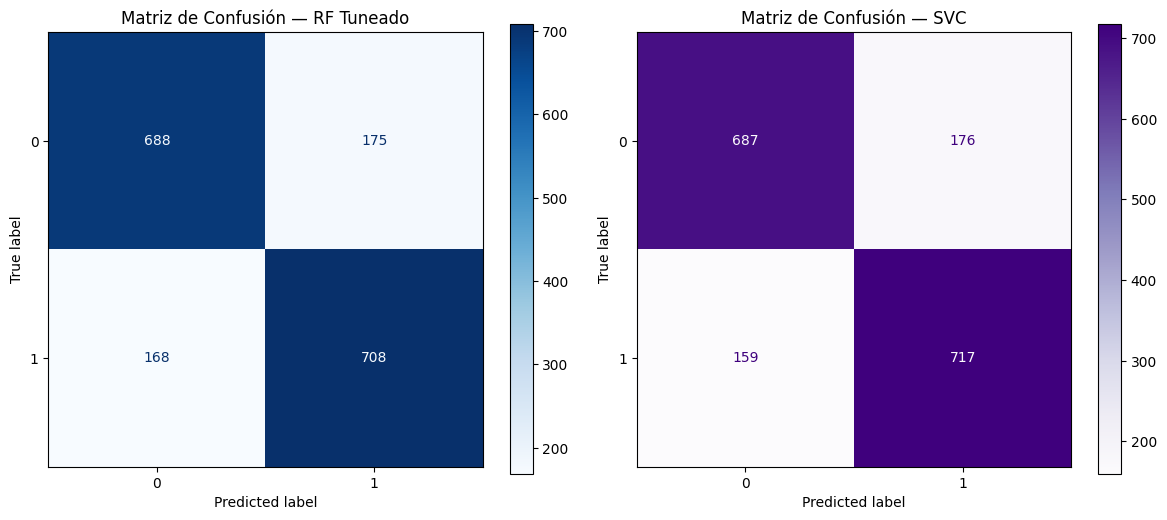

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

y_pred_rf = modelo_rf_tuned.predict(X_test)
y_pred_svc = modelo_svc_final.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de Confusión — RF Tuneado")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, cmap="Purples", ax=axes[1])
axes[1].set_title("Matriz de Confusión — SVC")
plt.tight_layout()
plt.show()

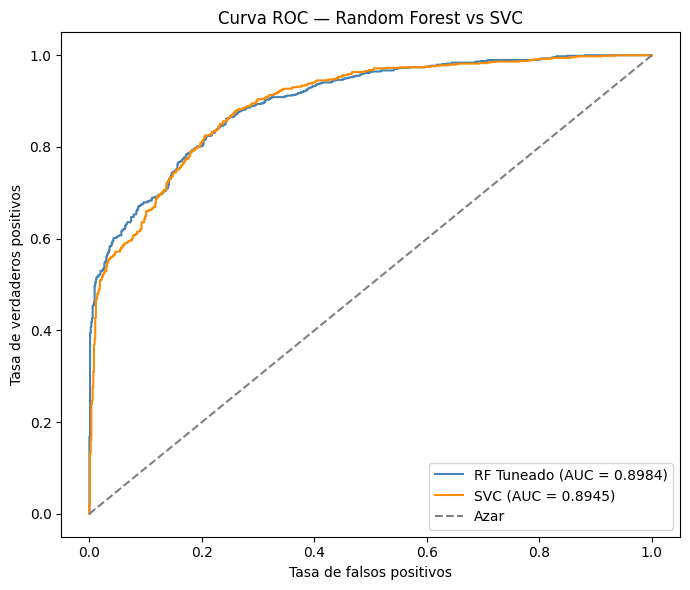

In [14]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, modelo_rf_tuned.predict_proba(X_test)[:, 1])
fpr_svc, tpr_svc, _ = roc_curve(y_test, modelo_svc_final.predict_proba(X_test)[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f"RF Tuneado (AUC = {comparacion_final.loc['ROC-AUC', 'Random Forest tuneado']:.4f})", color="steelblue")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC = {comparacion_final.loc['ROC-AUC', 'SVC tuneado']:.4f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos"); plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — Random Forest vs SVC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Interpretación:** el SVC captura más verdaderos positivos (717 vs 708) y
reduce falsos negativos (159 vs 168) frente al RF, sin sacrificar
especificidad (687 vs 688 verdaderos negativos). Esto se traduce en un
Recall notablemente mejor (+0.0103) y, con ello, F1 y Accuracy también
mejores. Sin embargo, el RF mantiene una ligera ventaja en ROC-AUC
(0.8984 vs 0.8945): su ordenamiento de probabilidades a lo largo de todos
los umbrales posibles es marginalmente mejor, aunque en el punto de
operación real (umbral 0.5) el SVC gana.

## Decisión: Estrategia Dual

- **Implementación principal (automatizada): SVC.** Con la infraestructura
  computacional adecuada, es el modelo a usar: su Recall más alto significa
  detectar a más pasajeros que sí fueron transportados.
- **Protocolo de respaldo (interpretación/operación manual): Random
  Forest.** El SVC es una "caja negra" matemática difícil de interpretar
  sin cómputo; el RF, al basarse en reglas de división explícitas, permite
  extraer árboles representativos y entender el porqué de una predicción —
  valioso si se necesita justificar decisiones operativas sin depender
  de una API o servidor corriendo.

Esta es la razón por la que la Sección 7 exporta **ambos** modelos, y por
la que el dashboard de la siguiente etapa debe permitir elegir cuál usar.

# 7. Exportación de Modelos

Exportamos los tres artefactos que necesita el dashboard de la siguiente
etapa: el preprocesador (`SpaceshipPreprocessor` ya ajustado) y los dos
modelos de la estrategia dual (RF y SVC), para que la interfaz pueda
elegir cuál usar sin tener que reentrenar nada.

In [15]:
import joblib

MODELOS = Path("..") / "data" / "modelos_full"
MODELOS.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocesador, MODELOS / "preprocesador.pkl")
joblib.dump(modelo_rf_tuned, MODELOS / "modelo_rf_final.pkl")
joblib.dump(modelo_svc_final, MODELOS / "modelo_svc_final.pkl")

print("Modelos exportados en:", MODELOS)
for archivo in MODELOS.iterdir():
    print(" -", archivo.name)

Modelos exportados en: ..\data\modelos_full
 - modelo_rf_final.pkl
 - modelo_svc_final.pkl
 - preprocesador.pkl


**Nota:** guardamos estos tres artefactos en `data/modelos_full/` (subcarpeta
propia dentro de `data/`, que ya comparten `Notebooks/` y `Reto_Full/`) para
no confundirlos con los `.pkl` individuales que cada integrante generó en el
Avance 3 (`modelo_knn.pkl`, `modelo_svc_grid.pkl`, etc.), que corresponden a
experimentos intermedios, no al modelo final de la estrategia dual.

# 8. Conclusión Final del Equipo

## ¿Qué aprendieron del comportamiento de los modelos sobre este dataset a lo largo de los tres avances?

Aprendimos que el rendimiento no siempre crece de manera proporcional a la
complejidad computacional. Los modelos basados en ensambles de árboles
(Random Forest) alcanzaron muy rápido un techo de rendimiento con
configuraciones relativamente conservadoras (`max_depth=10`), y la
sintonización exhaustiva posterior ofreció retornos decrecientes, mejorando
el F1-score de manera casi marginal (~+0.01 en CV).

Por otro lado, comprobamos que los modelos de frontera geométrica (SVC con
kernel `rbf`) tienen la capacidad de proyectar las interacciones de este
dataset a espacios donde logran aislar mejor la clase positiva,
consiguiendo un salto real en Recall. Finalmente, aprendimos a valorar el
trade-off operativo: un SVC puede ganar en precisión estricta, pero un
Random Forest gana en interpretabilidad y estabilidad, demostrando que en
ciencia de datos el "mejor modelo" depende de las condiciones de
implementación — de ahí la estrategia dual de la Sección 6.

## ¿Qué cambiarían en el pipeline de preprocesamiento sabiendo lo que saben ahora?

Sabiendo que modelos sensibles a las distancias geométricas (como el SVC)
terminaron ofreciendo el mejor rendimiento predictivo, el preprocesamiento
debió enfocarse más en la distribución de las variables numéricas. En vez
de un escalado estándar, se podrían explorar transformaciones como
Yeo-Johnson para suavizar el sesgo en las variables de gasto de forma más
flexible que `log1p`.

También repensaríamos el tratamiento de `Deck` y `CabinNum`: el Apéndice A
de este notebook explora justamente si tratar `Deck` como variable ordinal
(en vez de one-hot) cambia algo, y el Apéndice B revisa si `group_size`
está aportando la información que se asumió que aportaba.

## ¿Qué esperan mejorar en la siguiente iteración?

Para una futura iteración, el objetivo sería enfocarnos agresivamente en
Feature Engineering adicional (por ejemplo, gasto total acumulado o
proporción de gasto por categoría dentro de cada pasajero) y experimentar
con arquitecturas de Gradient Boosting (XGBoost, LightGBM), que combinan la
robustez de los árboles con optimización secuencial. Un **Stacking
Ensemble** que combine el ordenamiento probabilístico del Random Forest con
la sensibilidad de frontera del SVC es también un camino natural, dado que
ambos modelos demostraron fortalezas complementarias en la Sección 6.

# Apéndice A: Deck como Variable Ordinal

En el pipeline principal, `Deck` se codificó con One-Hot Encoding (Avance 1,
Sección 5) porque, a priori, no había una razón matemática para imponerle
un orden. Aquí probamos la alternativa que sugirió el profesor: tratar
`Deck` como **ordinal**.

**Justificación del orden elegido:** en vez de usar el orden alfabético
(A→G→T), que no tiene ningún fundamento salvo la convención de nombrado,
usamos un orden **empírico**: ordenamos las cubiertas por su tasa de
`Transported`, de menor a mayor. Esto convierte a `Deck` en una variable
que captura directamente "qué tan asociada está esta cubierta con ser
transportado", en vez de imponerle una jerarquía física (proa/popa) que no
sabemos si el modelo necesita.

In [16]:
tasa_transportado_deck = (
    df_prep_deck_temp := df_train.assign(
        Deck=df_train["Cabin"].str.split("/").str[0]
    )
)
tasa_deck = df_prep_deck_temp.groupby("Deck")["Transported"].mean().sort_values()
print(tasa_deck)

orden_deck = tasa_deck.index.tolist()
print("\nOrden ordinal (de menor a mayor tasa de Transported):", orden_deck)

Deck
T    0.200000
E    0.357306
D    0.433054
F    0.439871
A    0.496094
G    0.516217
C    0.680054
B    0.734275
Name: Transported, dtype: float64

Orden ordinal (de menor a mayor tasa de Transported): ['T', 'E', 'D', 'F', 'A', 'G', 'C', 'B']


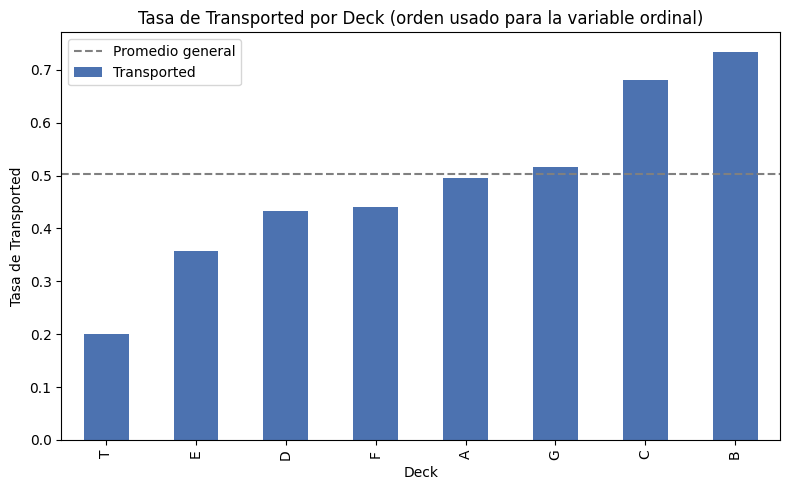

In [17]:
plt.figure(figsize=(8, 5))
tasa_deck.plot(kind="bar", color="#4C72B0")
plt.axhline(df_train["Transported"].mean(), color="gray", linestyle="--", label="Promedio general")
plt.ylabel("Tasa de Transported")
plt.title("Tasa de Transported por Deck (orden usado para la variable ordinal)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
class SpaceshipPreprocessorDeckOrdinal(SpaceshipPreprocessor):
    """Igual que SpaceshipPreprocessor, pero Deck se codifica como ordinal
    (según tasa de Transported) en vez de One-Hot Encoding."""

    def __init__(self, orden_deck):
        super().__init__()
        self.orden_deck = orden_deck

    def _codificar(self, df):
        df["group"] = df["PassengerId"].str.split("_").str[0]
        df["group_size"] = df["group"].map(df["group"].value_counts())
        df.drop(columns=["Cabin", "PassengerId", "group"], inplace=True, errors="ignore")

        df["CabinNumBin"] = pd.cut(df["CabinNum"], bins=self.bins_cabin, labels=self.labels_cabin)
        df.drop(columns=["CabinNum"], inplace=True)

        df["HasSpent"] = (df[SPEND_COLS].sum(axis=1) > 0).astype(int)
        df["CryoSleep"] = df["CryoSleep"].astype(int)
        df["Side"] = df["Side"].map({"P": 0, "S": 1})
        if "Transported" in df.columns:
            df["Transported"] = df["Transported"].astype(int)

        # --- Única diferencia: Deck ordinal en vez de one-hot ---
        mapa_deck = {deck: i for i, deck in enumerate(self.orden_deck)}
        df["Deck_ordinal"] = df["Deck"].map(mapa_deck)
        df.drop(columns=["Deck"], inplace=True)

        df = pd.get_dummies(df, columns=["HomePlanet", "Destination", "CabinNumBin"], drop_first=True, dtype=int)
        return df

In [19]:
preprocesador_ordinal = SpaceshipPreprocessorDeckOrdinal(orden_deck)
preprocesador_ordinal.fit(df_train)
df_prep_ordinal = preprocesador_ordinal.transform(df_train)

X_ord = df_prep_ordinal.drop(columns=["Transported"])
y_ord = df_prep_ordinal["Transported"]
X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(
    X_ord, y_ord, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ord
)

modelo_rf_ordinal = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)
modelo_rf_ordinal.fit(X_train_ord, y_train_ord)
f1_ordinal = f1_score(y_test_ord, modelo_rf_ordinal.predict(X_test_ord))

print("Shape con Deck ordinal:", df_prep_ordinal.shape)
print(f"F1 (RF base, Deck ordinal):    {f1_ordinal:.4f}")
print(f"F1 (RF base, Deck one-hot):    {f1_score(y_test, modelo_rf_base.predict(X_test)):.4f}")

Shape con Deck ordinal: (8693, 21)
F1 (RF base, Deck ordinal):    0.8014
F1 (RF base, Deck one-hot):    0.8000


**Interpretación:**

Tratar `Deck` como variable ordinal (según tasa de `Transported`) dio un F1
de 0.8014, ligeramente mejor que el 0.8000 de la versión One-Hot Encoding
(+0.0014). Además, el dataset se redujo de 27 a solo 21 columnas — las 7
columnas dummy de `Deck` se comprimieron en una sola variable ordinal.

La mejora es pequeña pero consistente con la teoría: al ordenar las
cubiertas por su tasa real de `Transported`, la variable ordinal captura
directamente una relación monótona que el modelo puede aprovechar con un
solo split por umbral, en vez de tener que combinar información repartida
en 7 columnas binarias. Con una diferencia de apenas +0.0014, esto no es
una mejora dramática, pero sí confirma que la codificación ordinal no
pierde información frente al one-hot — y de hecho reduce la dimensionalidad
del dataset en 6 columnas sin costo de desempeño. Esto sería especialmente
relevante para modelos sensibles a la dimensionalidad como KNN (Sección 5),
aunque aquí solo se probó con Random Forest.

**Advertencia sobre esta estrategia:** el orden ordinal se derivó de la
tasa de `Transported` calculada sobre `train`, es decir, usa información
del target. Esto es válido como exploración (y es habitual en *target
encoding*), pero es importante no confundirlo con un orden "objetivo" de
las cubiertas — es un orden aprendido de los datos de entrenamiento, no
una propiedad física de la nave. Por eso esta variante se documenta como
apéndice exploratorio y no reemplaza la codificación One-Hot del pipeline
principal, que es más conservadora y no depende del target para definir la
codificación.

# Apéndice B: Verificación de Varianza por `group_size`

En el Avance 1 se justificó incluir `group_size` con una gráfica (crosstab
de `Transported` por tamaño de grupo), pero sin una prueba estadística
formal. Aquí verificamos con más rigor si `group_size` realmente explica
varianza significativa en el comportamiento de los pasajeros, o si su
efecto visual podría deberse al azar (especialmente en los grupos grandes,
que tienen pocas observaciones).

Usamos dos pruebas complementarias:
1. **ANOVA de un factor** sobre el gasto total, para ver si el *nivel* de
   gasto varía significativamente entre tamaños de grupo (variable
   continua).
2. **Prueba Chi-cuadrado de independencia** entre `group_size` y
   `Transported`, para ver si hay una asociación estadísticamente
   significativa con el target (variable categórica/binaria).

In [20]:
from scipy import stats

df_grupo_temp = df_train.copy()
df_grupo_temp["group"] = df_grupo_temp["PassengerId"].str.split("_").str[0]
df_grupo_temp["group_size"] = df_grupo_temp["group"].map(df_grupo_temp["group"].value_counts())
df_grupo_temp["gasto_total"] = df_grupo_temp[SPEND_COLS].sum(axis=1)

print("Distribución de group_size:")
print(df_grupo_temp["group_size"].value_counts().sort_index())

Distribución de group_size:
group_size
1    4805
2    1682
3    1020
4     412
5     265
6     174
7     231
8     104
Name: count, dtype: int64


<Figure size 900x500 with 0 Axes>

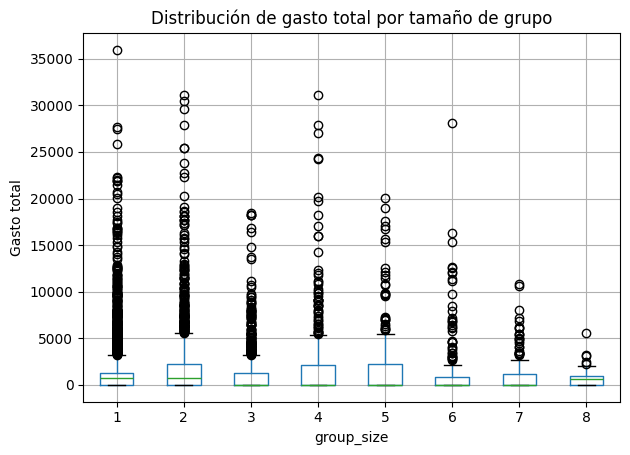

In [21]:
plt.figure(figsize=(9, 5))
df_grupo_temp.boxplot(column="gasto_total", by="group_size")
plt.ylabel("Gasto total")
plt.title("Distribución de gasto total por tamaño de grupo")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [22]:
# --- Prueba 1: ANOVA sobre gasto_total entre grupos de group_size ---
grupos_gasto = [
    grupo["gasto_total"].dropna().values
    for _, grupo in df_grupo_temp.groupby("group_size")
]
f_stat, p_valor_anova = stats.f_oneway(*grupos_gasto)
print(f"ANOVA — gasto_total entre tamaños de grupo: F={f_stat:.4f}, p-valor={p_valor_anova:.4e}")

# --- Prueba 2: Chi-cuadrado entre group_size y Transported ---
tabla_contingencia = pd.crosstab(df_grupo_temp["group_size"], df_grupo_temp["Transported"])
chi2, p_valor_chi2, dof, _ = stats.chi2_contingency(tabla_contingencia)
print(f"Chi-cuadrado — group_size vs Transported: chi2={chi2:.4f}, gl={dof}, p-valor={p_valor_chi2:.4e}")

ANOVA — gasto_total entre tamaños de grupo: F=15.7659, p-valor=1.0610e-20
Chi-cuadrado — group_size vs Transported: chi2=145.2815, gl=7, p-valor=3.9709e-28


**Interpretación:**

- **ANOVA:** F=15.77, p-valor=1.06×10⁻²⁰ (≪ 0.05). El gasto total promedio
  **sí difiere significativamente** entre tamaños de grupo — no es ruido
  estadístico. El boxplot lo confirma visualmente: los grupos más grandes
  (6-8 personas) tienden a un gasto mediano más bajo y menos dispersión de
  outliers extremos que los pasajeros que viajan solos (`group_size=1`),
  donde se concentran los valores de gasto más altos.
- **Chi-cuadrado:** χ²=145.28, gl=7, p-valor=3.97×10⁻²⁸ (≪ 0.05).
  `group_size` y `Transported` **no son independientes**: hay una
  asociación real y muy significativa entre el tamaño del grupo y la
  probabilidad de ser transportado.

**Conclusión del apéndice:** ambas pruebas confirman con alta significancia
estadística (p-valores extremadamente pequeños, no solo "por debajo de
0.05") la decisión del Avance 1 de incluir `group_size` como feature. No es
una variable redundante ni un patrón espurio de la muestra: viajar en grupo
está asociado tanto a un patrón de gasto distinto como a una probabilidad
de transporte distinta, dos señales independientes que justifican
conservarla en el pipeline principal.